In [1]:
!pip install numpy pandas matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [3]:
iris = load_iris()

X = iris.data[:, :2]
y = iris.target

print("Dataset Shape:", X.shape)

Dataset Shape: (150, 2)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
k_values = [1,3,5,7,9]

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

    print("k =",k," Accuracy =",acc)

k = 1  Accuracy = 0.7111111111111111
k = 3  Accuracy = 0.7555555555555555
k = 5  Accuracy = 0.7777777777777778
k = 7  Accuracy = 0.8
k = 9  Accuracy = 0.8


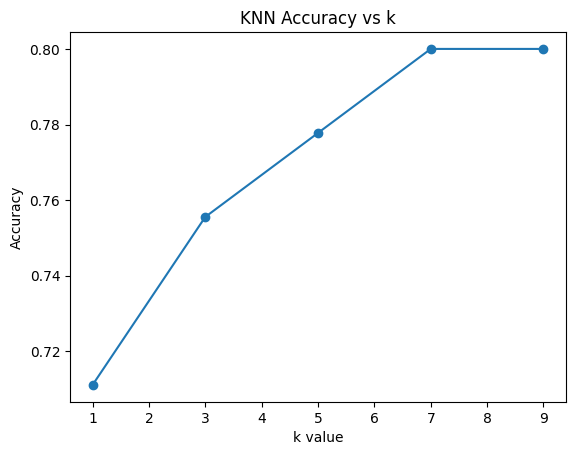

In [6]:
plt.plot(k_values, accuracies, marker="o")

plt.xlabel("k value")
plt.ylabel("Accuracy")

plt.title("KNN Accuracy vs k")

plt.show()

In [7]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", names=["label","message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df["label"] = df["label"].map({"ham":0,"spam":1})

df["message"] = df["message"].str.lower()

df.head()

,label,message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label"], test_size=0.3, random_state=42
)

In [10]:
vectorizer = CountVectorizer(max_features=1000)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [11]:
mnb = MultinomialNB()

mnb.fit(X_train_vec, y_train)

y_pred = mnb.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.9850478468899522
Precision: 0.9344978165938864
Recall: 0.9553571428571429


In [12]:
X_train_num = np.array([[len(msg), len(msg.split())] for msg in X_train])

X_test_num = np.array([[len(msg), len(msg.split())] for msg in X_test])

In [13]:
gnb = GaussianNB()

gnb.fit(X_train_num, y_train)

y_pred_gnb = gnb.predict(X_test_num)

print("Gaussian NB Accuracy:", accuracy_score(y_test, y_pred_gnb))

Gaussian NB Accuracy: 0.8606459330143541


In [14]:
probs = mnb.predict_proba(X_test_vec[:5])

print("Probability Output:")
print(probs)

Probability Output:
[[9.99996727e-01 3.27291368e-06]
 [9.99998766e-01 1.23414477e-06]
 [9.99999999e-01 8.04061209e-10]
 [9.99984192e-01 1.58076942e-05]
 [9.99959538e-01 4.04623847e-05]]
